# Лабораторная работа: Абелевы группы

## Описание

Необходимо реализовать класс **конечно порождённой абелевой группы** `AbelianGroup`.  
Абелева группа $G$ строится как фактор свободной группы $\mathbb{Z}^n$ по соотношениям, то есть по порождающим ядра факторизации.

- **Файлы решения**:
  - **Python**: `solution.py`
  - **C++**: `solution.cpp`
- **Тесты**:
  - Python: `test_public.py`
  - C++: `test_public.cpp`
- **Дедлайн**: 23:59, 20 мая
- **Контакты**:  
  По всем вопросам — в Telegram к Максиму Малкову [@Serious_Meow](https://t.me/Serious_Meow).

> **Важно**: Задания последовательные — многие методы полагаются на реализацию `smith_normal_form` и `AbelianGroup.invariant_factors`.

---

## 1. Общие требования

1. **Язык**: Python ≥3.11 или C++20  
2. **Подключаемые библиотеки**:  
   - Python: [SymPy](https://docs.sympy.org/latest/tutorials/intro_tutorial/matrices.html)  
   - C++: [Eigen](https://eigen.tuxfamily.org/dox/classEigen_1_1Matrix.html)  
3. **Запуск тестов**:
   - **Python**:
     ```bash
     python3 -m venv .venv
     source .venv/bin/activate
     python3 -m pip install -r requirements.txt
     python3 -m pytest
     ```
     Или:
     ```bash
     python3 test_public.py
     ```
   - **C++**:
     ```bash
     mkdir build && cd build
     cmake ..
     make run-tests       # или make run-tests -j8
     ```

---

## 2. Методы и функции для реализации

### 2.1. smith_normal_form(A) (5 б.)

Для ненулевой целочисленной матрицы $A$ размера $n \times k$ вернуть тройку $(S, D, T)$, где:

- $D$ — диагональная $n \times k$ матрица целых неотрицательных чисел, у которой каждый ненулевой диагональный элемент делится на предыдущий. Нулевые элементы на диагонали (если есть) идут в конце.
- $S$ — целочисленная обратимая матрица размера $n \times n$.
- $T$ — целочисленная обратимая матрица размера $k \times k$.
- Условие: $\displaystyle D = S \cdot A \cdot T$.

## 3. Особенности работы с библиотеками

### 3.1. Python + SymPy

- Векторы — только столбцы:  
  ```python
  Matrix([a, b]) == Matrix([[a], [b]])
  # Обе имеют размер 2×1

- Столбцы матрицы `M`:

  ```python
  [M.col(i) for i in range(M.cols)]
  ```

- Операции над строками/столбцами:
  `elementary_row_op`, `elementary_col_op`.
- Граничный случай: `M.diagonal()` падает на матрицах с 0 строк или 0 столбцов — обрабатывать особо!
- Разрешено:

  - `M.det()`, `M.inv()`, `M**(-1)`
  - `sympy.lcm(a, b)`, `sympy.igcd(a, b)`
  - Конструкторы: `eye`, `zeros`, `diag`
  - Стандартные библиотеки Python (`functools`, `itertools`, …)

### 3.2. C++ + Eigen

- Используется `int64_t` для элементов, `ssize_t` для размеров.
- Инициализация:

  ```cpp
  Vector v{2};
  v << 1, 2;
  ```
- Размеры: `M.rows()`, `M.cols()`. Доступ: `M(r, c)`.
- Операции над строками/столбцами (векторизованы), перестановка:
  `M.row(a).swap(M.row(b))`.
- Разрешено:

  - `M.determinant()`, пользовательская `inverse()`
  - `Matrix::Identity()`, `Matrix::Zero()`
  - `std::lcm`, `std::gcd`
  - STL целиком

---

## 4. Оценивание

- Сумма баллов делится на 1.3 и нормируется до 10.
- **Бонус** +0.5 балла за прохождение дополнительного теста `test_zero_dim` для группы $\mathbb{Z}^0$.

---

## 5. Сдача работы

1. Внести свои данные в `PersonalInfo` / `personal_info` строго как в ведомости.
2. Залить только файл решения (`solution.py` или `solution.cpp`) в Classroom.
3. Убедиться, что все публичные тесты проходят (и дополнительный тест для ЗБЧ $\mathbb{Z}^0$, если хотите бонус).

Удачи!


In [ ]:
#%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [3]:
from functools import cache
from typing import List, Optional, Tuple
from typing_extensions import Self

from sympy import Matrix, eye, zeros, lcm, oo
from sympy.matrices.dense import MutableDenseMatrix
from sympy.matrices.immutable import ImmutableMatrix
from sympy.matrices.matrixbase import MatrixBase
from sympy.core.numbers import Infinity

# Добавил сам, в задании написано, что такое юзать можно
from sympy import gcd

# впишите свои данные как в ведомости
PersonalInfo = {
    "группа": "242",
    "Фамилия": "Наседкин",
    "Имя": "Дмитрий",
}

## 2. Методы и функции для реализации

### 2.1. smith_normal_form(A) (5 б.)

Для ненулевой целочисленной матрицы $A$ размера $n \times k$ вернуть тройку $(S, D, T)$, где:

- $D$ — диагональная $n \times k$ матрица целых неотрицательных чисел, у которой каждый ненулевой диагональный элемент делится на предыдущий. Нулевые элементы на диагонали (если есть) идут в конце.
- $S$ — целочисленная обратимая матрица размера $n \times n$.
- $T$ — целочисленная обратимая матрица размера $k \times k$.
- Условие: $\displaystyle D = S \cdot A \cdot T$.

In [4]:
def smith_normal_form(A: MatrixBase) -> Tuple[Matrix, Matrix, Matrix]:
    """
    Для ненулевой целочисленной матрицы A размера n*k возвращает тройку S, D, T, где
     S - обратимая над Z целочисленная матрица n*n,
     D - диагональная целочисленная матрица n*k, в которой каждый диагональный элемент делит следующий,
     T - обратимая над Z целочисленная матрица k*k,
    причём D = S*A*T
    """

    D = A
    n, k = A.shape

    S = eye(n)
    T = eye(k)

    i = j = 0
    while i < n and j < k:
        # 1) ищем ненулевой элемент с наименьшим модулем в D[i:, j:]
        best = None
        for r in range(i, n):
            for c in range(j, k):
                if D[r, c] != 0:
                    if best is None or abs(D[r, c]) < abs(D[best[0], best[1]]):
                        best = (r, c)
        if best is None:
            break
        bi, bj = best

        # 2) переставляем строки/столбцы, чтобы маленький элемент оказался в (i, j)
        if bi != i:
            D = D.elementary_row_op("n<->m", row1=i, row2=bi)
            S = S.elementary_row_op("n<->m", row1=i, row2=bi)
        if bj != j:
            D = D.elementary_col_op("n<->m", col1=j, col2=bj)
            T = T.elementary_col_op("n<->m", col1=j, col2=bj)

        # 3) делаем опорный элемент > 0
        if D[i, j] < 0:
            D = D.elementary_row_op("n->kn", row=i, k=-1)
            S = S.elementary_row_op("n->kn", row=i, k=-1)

        # 4) Пока снизу и правее нас есть элемент который не делится на нас, 
        # делим с остатком и меняем строчки/столбцы, уменьшая c_{ij}
        def NormalizeRowsAndColumns():
            nonlocal D, S, T

            while True:
                reduced = False
                for r in range(i + 1, n):
                    if D[r, j] % D[i, j] != 0:
                        q = D[r, j] // D[i, j]
                        # row r -> row r - q*row i
                        D = D.elementary_row_op("n->n+km", row=r, k=-q, row2=i)
                        S = S.elementary_row_op("n->n+km", row=r, k=-q, row2=i)

                        D = D.elementary_row_op("n<->m", row1=r, row2=i)
                        S = S.elementary_row_op("n<->m", row1=r, row2=i)

                        reduced = True
                        break
                if reduced:
                    continue

                for c in range(j + 1, k):
                    if D[i, c] % D[i, j] != 0:
                        q = D[i, c] // D[i, j]
                        # col c -> col c - q*col j
                        D = D.elementary_col_op("n->n+km", col=c, k=-q, col2=j)
                        T = T.elementary_col_op("n->n+km", col=c, k=-q, col2=j)

                        D = D.elementary_col_op("n<->m", col1=c, col2=j)
                        T = T.elementary_col_op("n<->m", col1=c, col2=j)

                        reduced = True
                        break
                if reduced:
                    continue

                break

        NormalizeRowsAndColumns()

        # 5) Пока какой-то элемент c_{zw} не делится на нас в подматрице снизу-справа, то
        # Сделаем c_{zj} = 0, после чего прибавим к j-ому столбцу w-ую строку и снова запустим шаг 4
        # таким образом добьемся, что рано или поздно c_{ij} будет делить все элементы подматрицы (снизу-справа)
        def NormalizeMatrix():
            nonlocal D, S, T

            while True:
                reduced = False
                for z in range(i + 1, n):
                    for w in range(j + 1, k):
                        if D[z, w] % D[i, j] != 0:
                            q = D[z, j] // D[i, j]
                            # row z -> row z - q*row i
                            D = D.elementary_row_op("n->n+km", row=z, k=-q, row2=i)
                            S = S.elementary_row_op("n->n+km", row=z, k=-q, row2=i)

                            # col j -> col j + col w
                            D = D.elementary_col_op("n->n+km", col=j, k=1, col2=w)
                            T = T.elementary_col_op("n->n+km", col=j, k=1, col2=w)

                            D = D.elementary_row_op("n<->m", row1=z, row2=i)
                            S = S.elementary_row_op("n<->m", row1=z, row2=i)

                            reduced = True
                            break
                    if reduced:
                        break
                if reduced:
                    NormalizeRowsAndColumns()
                    continue

                break

        NormalizeMatrix()

        # 6) Обнулим все элементы справа и снизу от c_{ij}
        for r in range(i + 1, n):
            q = D[r, j] // D[i, j]
            # row r -> row r - q*row i
            D = D.elementary_row_op("n->n+km", row=r, k=-q, row2=i)
            S = S.elementary_row_op("n->n+km", row=r, k=-q, row2=i)

            if D[r, j] != 0:
                raise RuntimeError

        for c in range(j + 1, k):
            q = D[i, c] // D[i, j]
            # col c -> col c - q*col j
            D = D.elementary_col_op("n->n+km", col=c, k=-q, col2=j)
            T = T.elementary_col_op("n->n+km", col=c, k=-q, col2=j)

            if D[i, c] != 0:
                raise RuntimeError

        # 7) Запустимся от подматрицы меньшего размера
        i += 1
        j += 1

    return S, D, T

In [5]:
def test_smith_normal_form():
    def check_snf(A, invariant_factors=None):
        S, D, T = smith_normal_form(A)
        assert D is not A, (
            "smith_normal_form не должна менять матрицу-аргумент или возвращать ее"
        )
        assert all(a.is_integer for a in S) and all(a.is_integer for a in T)
        u = D.diagonal() if 0 not in D.shape else []
        for i in range(len(u) - 1):
            if u[i] != 0:
                assert u[i + 1] % u[i] == 0
        assert S * A * T == D
        if invariant_factors is not None:
            assert list(u) == invariant_factors

    check_snf(Matrix([[2, 3], [5, 7]]), [1, 1])
    check_snf(Matrix([[2, 3], [5, 7], [1, 1]]), [1, 1])
    check_snf(Matrix([[3, 5, -4], [9, 7, 0]]), [1, 4])
    check_snf(Matrix([[1, 3], [-2, 1]]), [1, 7])
    for i in range(200):
        check_snf(randMatrix(3, 3, -20, 20))

test_smith_normal_form()

### 2.2. Методы класса `AbelianGroup`

Методы **не** имеют смысла без предыдущей реализации `smith_normal_form` и `invariant_factors`.

| Метод                                    | Описание                                                                                                                     | Баллы |
|------------------------------------------|------------------------------------------------------------------------------------------------------------------------------|-------|
| `invariant_factors()`                    | Возвращает список инвариантных множителей $(u_1, \dots, u_m$) (натуральные числа), дополненный нулями до длины `self.n`.  | 1     |
| `is_trivial()`                           | Возвращает `True`, если группа тривиальна (содержит только нейтральный элемент).                                            | 0.5   |
| `is_cyclic()`                            | Возвращает `True`, если группа циклическая (тривиальная считается циклической).                                             | 0.5   |
| `is_free()`                              | Возвращает `True`, если группа свободная.                                                                                   | 0.5   |
| `rank()`                                 | Возвращает ранг группы, если она свободная, иначе `None`.                                                                    | 0.5   |
| `is_finite()`                            | Возвращает `True`, если группа конечная.                                                                                     | 0.5   |
| `size()`                                 | Возвращает порядок группы, если она конечна, иначе `0`.                                                                      | 0.5   |
| `ord(v)`                                 | Возвращает порядок класса \(v\), если конечен, иначе `0`.                                                                    | 2     |
| `tor()`                                  | Возвращает подгруппу кручения в виде абстрактной абелевой группы.                                                            | 2     |

---

In [6]:
class AbelianGroup:
    """
    Абелева группа G строится как фактор свободной группы Z^n по своей подгруппе ker.
    """

    def __init__(self, n: int, K: MatrixBase | None = None):
        """
        Параметры:
            n:             неотрицательное число, равное рангу группы Z^n
            K:             матрица n*k, где столбцы - соотношения, то есть порождающие подгруппы ker.
        """
        self.n = n
        K = K if K is not None else zeros(self.n, 0)
        self.K = ImmutableMatrix(K)
        assert self.K.shape[0] == self.n

        # делаем self.K непустым, чтобы работал .diagonal()
        if self.K.shape[1] == 0:
            self.K = zeros(self.n, 1)

    @cache
    def _SNF(self) -> Tuple[Matrix, Matrix, Matrix]:
        """
        Возвращает нормальную форму Смита для матрицы `self.K`.
        Если `self.K` пуста, то возвращает разложение с пустой матрицей D соответствующего размера.
        """
        return smith_normal_form(self.K)

    def invariant_factors(self) -> List[int]:
        """
        Возвращает список инвариантных множителей u_1,..,u_m (являются натуральными числами), дополненный нулями до длины `self.n`.
        Нули соответствуют свободным множителям, см. следствие 1 лекции 5.
        """
        _, D, _ = self._SNF()

        # Конечно есть "замечательный" diagonal(), но он падает на пустых матрицах, поэтому напишем свой
        diag = [int(D[d, d]) for d in range(min(D.rows, D.cols))]
        if len(diag) < self.n:
            diag += [0] * (self.n - len(diag))
        return diag

    def __repr__(self) -> str:
        return f"AbelianGroup({self.n}, kernel_gens={self.K})"

    def is_trivial(self) -> bool:
        """
        Возвращает `True`, если группа тривиальна (т.е. состоит из нейтрального элемента), и `False` иначе.
        """
        return self.size() == 1

    def is_cyclic(self) -> bool:
        """
        Возвращает `True`, если группа циклическая, и `False` иначе
        """
        # Циклическими являются только Z^0 - то есть тривиальная группа, или, Z или Z_n

        # Proof, что других нет:
        # Так как G = Z^r + Z_{d_1} + ... + Z_{d_k}, где d_i > 1 (Где d_i = 1 не беру в счет, они тривиальны).
        # Если r >= 2, то G очевидно нециклична,
        # Точно также если k >= 2, то она нециклична(так как инв. множ. делятся друг на друга, а не взаимно просты)
        # А G = Z + Z_d тоже нециклична

        inv = self.invariant_factors()
        cnt_nulls = inv.count(0)
        d = [u for u in inv if u > 1]
        if len(d) == 0:
            return cnt_nulls <= 1 # Z^0 и Z^1
        return cnt_nulls == 0 and len(d) == 1 # Z_n

    def is_free(self) -> bool:
        """
        Возвращает `True`, если группа свободная, и `False` иначе
        """
        # Группа свободна, если G = Z^r + Z_{d_1} + ... + Z_{d_k}, где d_i = 1
        # А значит нужно лишь проверить что все инв. множетели <= 1

        # Proof: На лекции 4 было доказано, что Z_n не свободна, где n > 1

        inv = self.invariant_factors()
        return all(u <= 1 for u in inv)

    def rank(self) -> Optional[int]:
        """
        Возвращает ранг группы, если она свободная, и `None` иначе
        """
        if not self.is_free():
            return None
        # Раз группа свободна, то как было доказано в критерии выше 
        # G = Z^r + Z_{d_1} + ... + Z_{d_k}, где d_i = 1
        # Отсюда очевидно, что rank(G) = кол-во нулей среди инв. множетелей
        return self.invariant_factors().count(0)

    def is_finite(self) -> bool:
        """
        Возвращает `True`, если группа конечная, и `False` иначе
        """
        # Группа G конечна, если она разлагается в прямую сумму примарных циклических подгрупп(с лекции 5)
        # То есть если среди инвариантных множетелей нет нулей
        return all(u != 0 for u in self.invariant_factors())

    def size(self) -> int:
        """
        Возвращает размер группы, если она конечна, и 0 иначе
        """
        # Если группа конечна, то порядок очевидно равен произведению модулей инв. множетелей
        # А если она бесконечна, то среди инв. множетелей есть 0, то есть произведение будет 0, то что нам и надо
        inv = self.invariant_factors()
        sz = 1
        for u in inv:
            sz *= abs(u)
        return sz

    def ord(self, v: Matrix) -> int:
        """
        Возвращает порядок элемента v, если он конечен, и 0 иначе
        """
        U, D, _ = self._SNF()
        # Меняем базис
        v_new = U * v
        inv = self.invariant_factors()

        # Если какой-то инв. множетель 0, и в этой коордианте не 0 -> очевидно бесконечный порядок
        for i, u in enumerate(inv):
            if u == 0 and int(v_new[i, 0]) != 0:
                return 0

        # Иначе для каждого инв. множетеля u > 0 считаем order_i = u / gcd(u, v_i % u)
        orders: List[int] = []
        for i, u in enumerate(inv):
            if u > 0:
                xi = int(v_new[i, 0]) % u
                gi = gcd(u, xi)
                orders.append(u // gi)

        # Если все u == 0, тогда и v_i = 0 для любого i -> порядок 1
        if not orders:
            return 1

        # Иначе порядок равен lcm всех orders
        order = 1
        for order_i in orders:
            order = lcm(order, order_i)
        return order

    def tor(self) -> "AbelianGroup":
        """
        Возвращает подгруппу кручения (как абстрактную группу)
        """
        # Если G = Z^r + Z_{d_1} + ... + Z_{d_k}, то
        # Tor(G) = Z_{d_1} + ... + Z_{d_k}

        inv = self.invariant_factors()
        torsion = [u for u in inv if u > 1]
        r = len(torsion)
        if r == 0:
            # Tor(G) = {0}
            return AbelianGroup(0)
        # строим матрицу r*r: diag(u1,…,ur)
        K_tor = Matrix.diag(torsion)
        return AbelianGroup(r, K_tor)


In [7]:
def test_invariant_factors():
    A = AbelianGroup(
        3,
        Matrix([
            [1, 3],
            [5, 8],
            [0, 0],
        ]),
    )
    assert A.invariant_factors() == [1, 7, 0]
    A = AbelianGroup(
        2,
        Matrix([
            [1, 3, 0],
            [5, 8, 0],
        ]),
    )
    assert A.invariant_factors() == [1, 7]


def test_is_trivial():
    A = AbelianGroup(
        3,
        Matrix([
            [1, 3],
            [5, 8],
            [0, 0],
        ]),
    )
    assert not A.is_trivial()
    A = AbelianGroup(
        2,
        Matrix([
            [1, 0, 3],
            [0, 2, 1],
        ]),
    )
    assert A.is_trivial()
    A = AbelianGroup(
        2,
        Matrix([
            [1, 3],
            [5, 8],
        ]),
    )
    assert not A.is_trivial()


def test_is_cyclic():
    A = AbelianGroup(3, Matrix([[2, 0, 0], [0, 2, 0], [0, 0, 2]]))
    assert not A.is_cyclic()
    B = AbelianGroup(2, Matrix([[1], [0]]))
    assert B.is_cyclic()
    C = AbelianGroup(1, Matrix([[4]]))
    assert C.is_cyclic()


def test_is_free():
    for n in range(1, 5):
        assert AbelianGroup(n).is_free()
    assert AbelianGroup(3, Matrix([[1], [1], [1]])).is_free()
    assert not AbelianGroup(2, Matrix([[2, 1], [0, 1]])).is_free()
    assert AbelianGroup(2, Matrix.eye(2)).is_free()  # trivial is free


def test_rank():
    for n in range(1, 5):
        assert AbelianGroup(n).rank() == n
    assert AbelianGroup(3, Matrix([[1], [0], [0]])).rank() == 2
    assert AbelianGroup(2, Matrix([[2, 1], [0, 1]])).rank() is None


def test_is_finite():
    assert AbelianGroup(0).is_finite()
    assert not AbelianGroup(2).is_finite()
    assert AbelianGroup(2, Matrix([[1, 0], [1, 2]])).is_finite()


def test_size():
    A = AbelianGroup(3, Matrix([[5, 0, 5], [7, 2, 0], [0, 0, 1]]))
    assert A.size() == 10

    B = AbelianGroup(3, Matrix([[4, 0, 0], [0, 5, 0], [0, 0, 2]]))
    assert B.size() == 4 * 5 * 2

    assert AbelianGroup(0).size() == 1
    assert AbelianGroup(1).size() == 0


def test_ord():
    K = Matrix([
        [1, 3],
        [5, 8],
        [0, 0],
    ])
    A = AbelianGroup(3, K)
    assert A.ord(Matrix([1, 0, 0])) == 7
    assert A.ord(Matrix([2, 10, 0])) == 1
    assert A.ord(Matrix([2, 1, 1])) == 0

    K = Matrix([
        [4, 8],
        [2, 10],
        [-100, 120],
    ])
    A = AbelianGroup(3, K)
    assert A.ord(Matrix([32, 31, 0])) == 2
    assert A.ord(Matrix([2, 1, -50])) == 2

    v = Matrix([1, 9])

    A = AbelianGroup(2, Matrix([[308, 2456], [103, 821]]))
    assert A.ord(v) == 100

    A = AbelianGroup(2, Matrix([[8000000001, 10000000001], [36000000004, 45000000004]]))
    assert A.ord(v) == 200000000

    A = AbelianGroup(
        2, Matrix([[48000000000035, 6000000000005], [8000000000007, 1000000000001]])
    )
    assert A.ord(v) == 250000000000


def test_tor():
    K = Matrix([
        [1, 3],
        [5, 8],
        [0, 0],
    ])
    A = AbelianGroup(3, K)
    A_Tor = A.tor()
    assert A_Tor.size() == 7


def test_zero_dim():
    A = AbelianGroup(0)
    assert A.is_free()
    assert A.is_trivial()
    assert A.is_cyclic()
    assert A.is_finite()

In [8]:
test_invariant_factors()
test_is_trivial()
test_is_cyclic()
test_is_free()
test_rank()
test_is_finite()
test_size()
test_ord()
test_tor()
test_zero_dim()

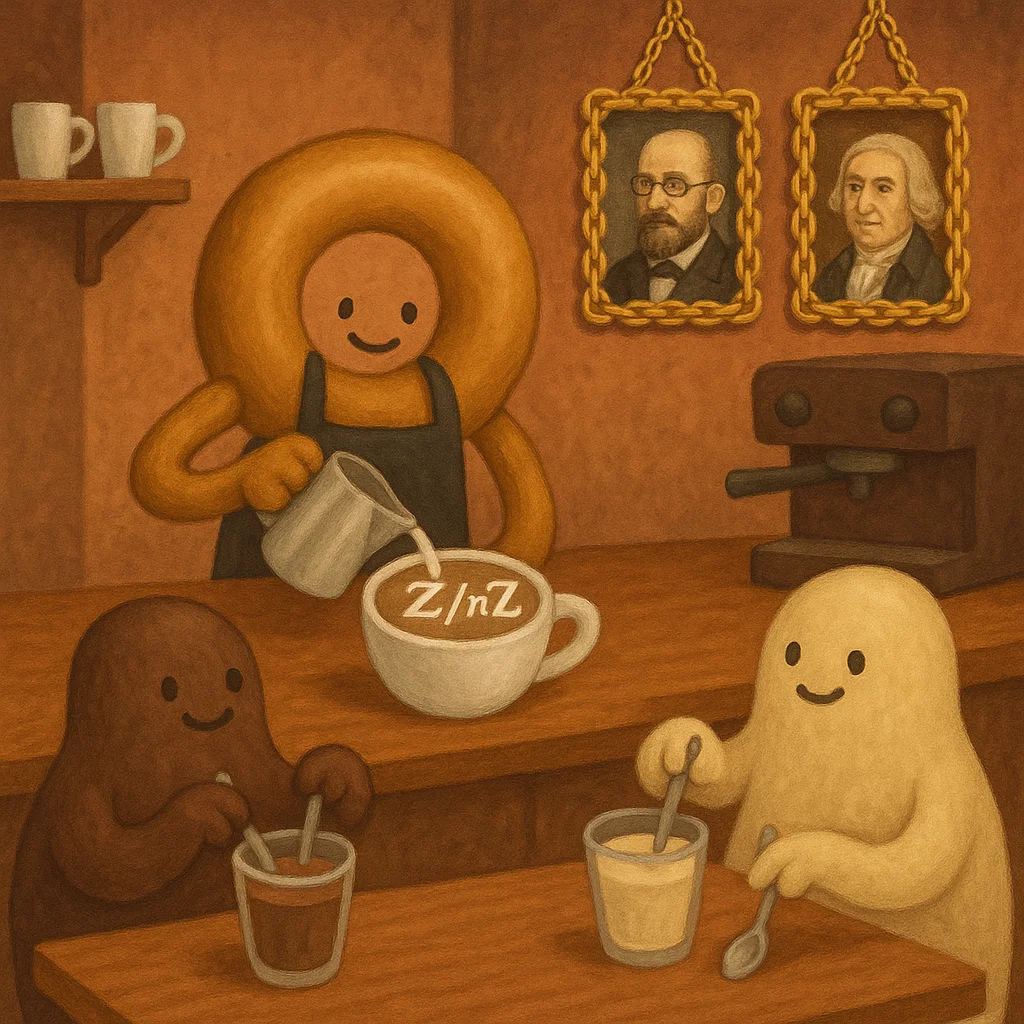